In [39]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.cutcount import (
    CeAcCutCountConfig, LinearWindowCal, EnergyWindow,
    half_width_from_resolution_pct, fit_linear_window_cal,
    estimate_ceac_mixture_cutcount,
)
from gamma.efficiency import EfficiencyFitSpec, fit_efficiency_model
from gamma.artifacts import ArtifactStore


In [2]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
store = ArtifactStore(repo_root / "artifacts")

# Load Calibrated Spectra

In [4]:
# --- Load calibrated spectra ---
exp_mix = "ANIL_MIX_SD__agg__bkgsub"
exp_ce  = "ANIL_CE_SD__agg__bkgsub"
exp_ac  = "ANIL_AC_SD__agg__bkgsub"
cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

In [5]:
# truth = store.load_ground_truth(exp_mix) 
# truth_labels = truth["labels"]

In [6]:
mix_cal = store.load_calibration(exp_mix, cal_tag)
ce_cal  = store.load_calibration(exp_ce, cal_tag)
ac_cal  = store.load_calibration(exp_ac, cal_tag)

# Load a Template

In [7]:
mix_label = mix_cal.labels[0]
ce_template_label = ce_cal.labels[0]   # choose your template
ac_template_label = ac_cal.labels[0]

print(f'Ce template: {ce_template_label}')
print(f'Ac template: {ac_template_label}')
print(f'Mix template: {mix_label}')

mix_spec = mix_cal.calibrated[mix_label]
ce_tpl   = ce_cal.calibrated[ce_template_label]

Ce template: 1.95312
Ac template: 1.95312
Mix template: 1.953:3.906


# Visualize templates, and confirm binning

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


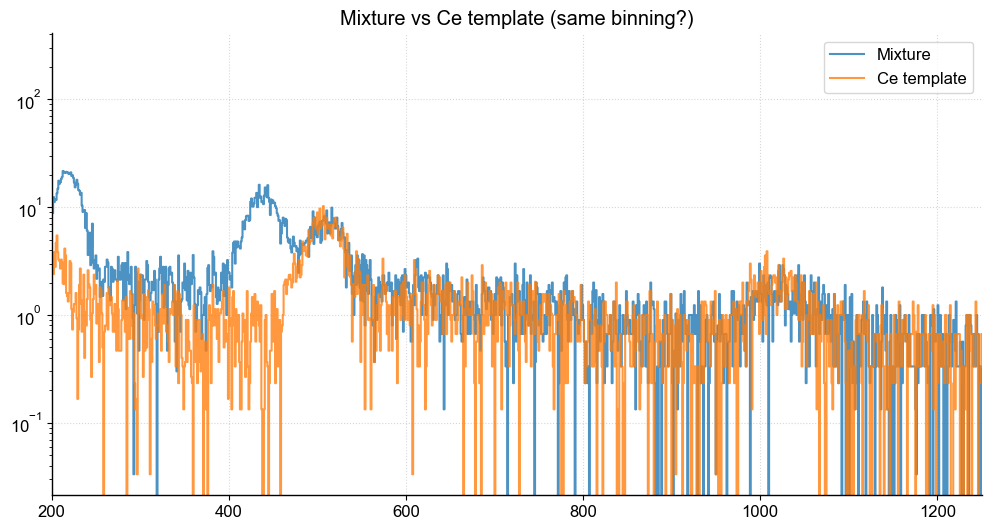

In [8]:
# --- Get arrays (adapt to your spectrum type) ---
x_keV = mix_spec['bin_centers_kev']
y_mix = mix_spec['counts_vals']
y_ce_template = ce_tpl['counts_vals']

plt.figure()
plt.step(x_keV, y_mix, where="mid", label="Mixture", alpha=0.8)
plt.step(x_keV, y_ce_template, where="mid", label="Ce template", alpha=0.8)
plt.yscale("log")
plt.xlim(200, 1250)
plt.legend()
plt.title("Mixture vs Ce template (same binning?)")
plt.show()

In [50]:
# This function will create the equivalent of the efficiency curve for the 
def fit_window_cal_via_efficiency(
    *,
    cal,                         # CalibrationResult (pure standards)
    label_to_activity_bq: dict,  # {label: activity_Bq}
    iso: str,
    peak_keV: float,
    resolution_pct_fwhm: float,
    nsigma: float,
    model_name: str,
    # through_origin: bool,
):
    # Build the same window definition cutcount uses
    hw = half_width_from_resolution_pct(peak_keV, resolution_pct_fwhm, nsigma=nsigma)
    win = EnergyWindow(center_keV=peak_keV, half_width_keV=hw)
    emin, emax = win.bounds()

    # Fit counts-in-window vs activity using efficiency.py
    spec = EfficiencyFitSpec(
        name=model_name,
        label_to_activity=label_to_activity_bq,  # IMPORTANT: Bq here
        model_type="linear",
        emin_keV=float(emin),
        emax_keV=float(emax),
        # rate_units="counts",   # IMPORTANT: we want raw window counts, not cpm
        livetime_s=60.0,       # use meta livetime if present; irrelevant for "counts"
    )

    model = fit_efficiency_model(cal, spec)

    # efficiency.py linear model: y = a*x + b  => a = counts/Bq, b = counts
    a = float(model.params["a"])
    b = float(model.params["b"])

    # Wrap as the cutcount calibration object
    cal_obj = LinearWindowCal(
        iso=iso,
        window=win,
        slope_counts_per_bq=a,
        intercept_counts=b,
        # through_origin = through_origin
    )

    return cal_obj, model

def plot_window_fit(model, title):
    A = np.array(model.meta["A_used"], dtype=float)
    R = np.array(model.meta["R_used"], dtype=float)
    a = float(model.params["a"])
    b = float(model.params["b"])

    xs = np.linspace(A.min(), A.max(), 200)
    ys = a*xs + b

    plt.figure()
    plt.scatter(A, R)
    plt.plot(xs, ys)
    plt.xlabel("Activity (Bq)")
    plt.ylabel("Window counts")
    plt.title(title)
    plt.show()
    plt.close()

    plt.figure()
    plt.scatter(A, R)
    plt.plot(xs, ys)
    plt.xlabel("Activity (Bq)")
    plt.ylabel("Window counts")
    plt.title(title+'ZOOM IN')
    plt.xlim(0,2500)
    plt.ylim(0,10000)
    plt.show()
    plt.close()

# Repeat: Load Calibration

In [43]:
# Example inputs (replace with your actual calibration result + truth map)
ce_cal_result = store.load_calibration(exp_ce, cal_tag)   # pure Ce standards
ac_cal_result = store.load_calibration(exp_ac, cal_tag)   # pure Ac standards

In [44]:
# Use your known standards + truth JSON to build activity->counts mapping
cfg = CeAcCutCountConfig(resolution_pct_fwhm=8.0, nsigma=2.0, ac_peak_keV=218.0)

In [45]:
# define the windows that correspond to these calibrations (must match cfg)
win_ce = EnergyWindow(cfg.ce_peak_keV, half_width_from_resolution_pct(cfg.ce_peak_keV, cfg.resolution_pct_fwhm, cfg.nsigma))
win_ac = EnergyWindow(cfg.ac_peak_keV, half_width_from_resolution_pct(cfg.ac_peak_keV, cfg.resolution_pct_fwhm, cfg.nsigma))

# define the windows that correspond to these calibrations (must match cfg)
win_ce = EnergyWindow(cfg.ce_peak_keV, half_width_from_resolution_pct(cfg.ce_peak_keV, cfg.resolution_pct_fwhm, cfg.nsigma))
win_ac = EnergyWindow(cfg.ac_peak_keV, half_width_from_resolution_pct(cfg.ac_peak_keV, cfg.resolution_pct_fwhm, cfg.nsigma))

In [46]:
# truth maps should be label -> activity in Bq
# (from your truth JSON for the PURE standards sets)

truth_ce = store.load_ground_truth(exp_ce)["labels"]
truth_ac = store.load_ground_truth(exp_ac)["labels"]

# build label -> activity_bq mapping for each iso
ce_truth_bq = {
    lbl: float(truth_ce[lbl]["ce134"]["value"])
    for lbl in truth_ce
    if "ce134" in truth_ce[lbl] and truth_ce[lbl]["ce134"].get("value") is not None
}

ac_truth_bq = {
    lbl: float(truth_ac[lbl]["ac225"]["value"])
    for lbl in truth_ac
    if "ac225" in truth_ac[lbl] and truth_ac[lbl]["ac225"].get("value") is not None
}

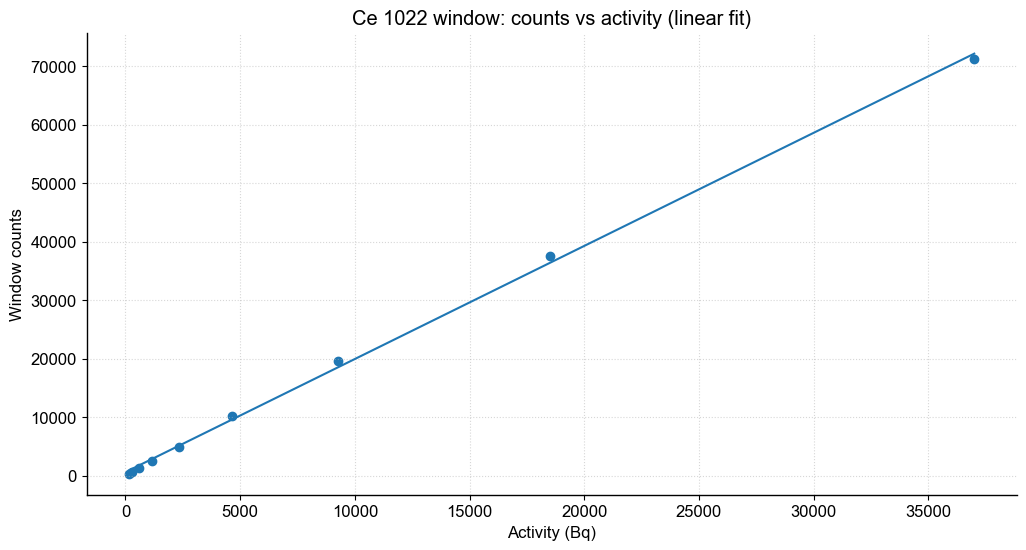

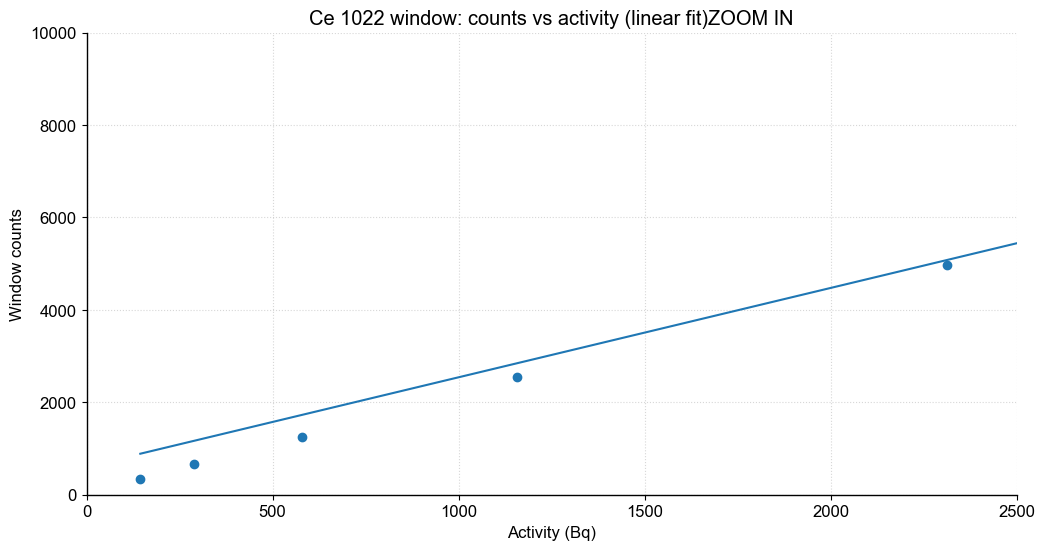

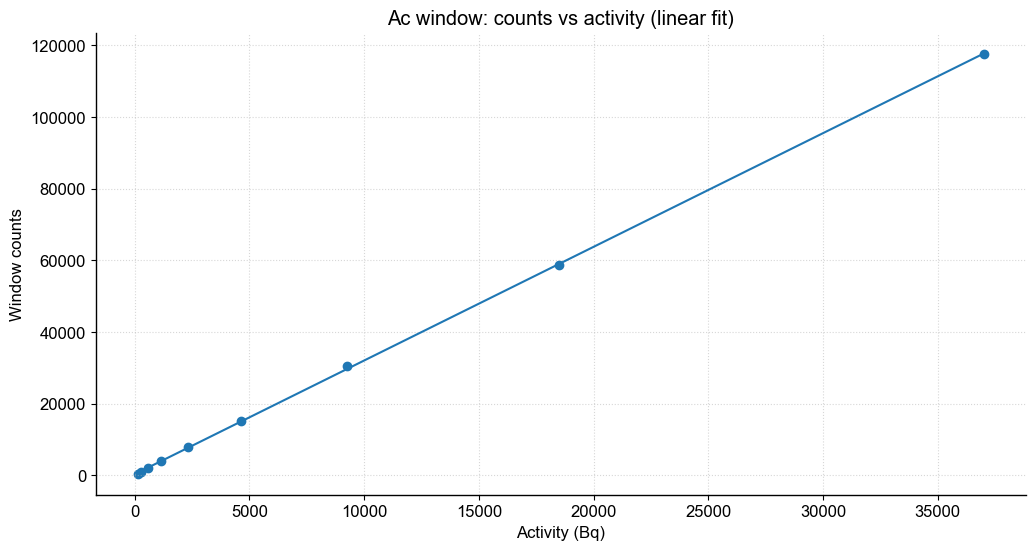

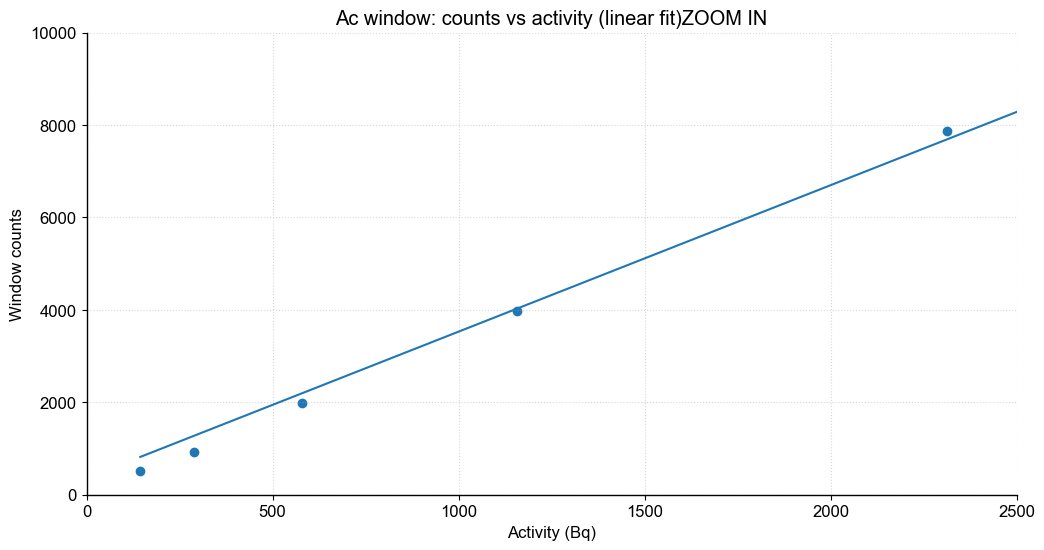

Ce slope counts/Bq: 1.933590892522804  intercept: 606.3190661478615
Ac slope counts/Bq: 3.169800834708931  intercept: 358.02668612192


In [51]:
ce_window_cal, ce_eff_model = fit_window_cal_via_efficiency(
    cal=ce_cal_result,
    label_to_activity_bq=ce_truth_bq,
    iso="ce134",
    peak_keV=1022.0,
    resolution_pct_fwhm=8.0,
    nsigma=2.0,
    model_name="ce134_win1022_counts_vs_bq_linear_v1",
    # through_origin=True,
)

ac_window_cal, ac_eff_model = fit_window_cal_via_efficiency(
    cal=ac_cal_result,
    label_to_activity_bq=ac_truth_bq,
    iso="ac225",
    peak_keV=218.0,
    resolution_pct_fwhm=8.0,
    nsigma=2.0,
    model_name="ac225_win218_counts_vs_bq_linear_v1",
    # through_origin=True,
)

plot_window_fit(ce_eff_model, "Ce 1022 window: counts vs activity (linear fit)")
plot_window_fit(ac_eff_model, "Ac window: counts vs activity (linear fit)")

print("Ce slope counts/Bq:", ce_window_cal.slope_counts_per_bq, " intercept:", ce_window_cal.intercept_counts)
print("Ac slope counts/Bq:", ac_window_cal.slope_counts_per_bq, " intercept:", ac_window_cal.intercept_counts)


# Do Cut-and-Count Estimation

In [52]:
est, extra = estimate_ceac_mixture_cutcount(
    x_keV=x_keV,
    y_mix=y_mix,
    y_ce_template=y_ce_template,
    ce_cal=ce_window_cal,
    ac_cal=ac_window_cal,
    config=cfg,
)

# fill ID fields
est.experiment_id = exp_mix
est.label = mix_label

In [53]:
# def plot_window(x, y, win, title):
#     lo, hi = win.bounds()
#     plt.figure()
#     plt.step(x, y, where="mid")
#     plt.axvline(lo); plt.axvline(hi)
#     plt.xlim(win.center_keV - 5*win.half_width_keV, win.center_keV + 5*win.half_width_keV)
#     plt.yscale("log")
#     plt.title(title)
#     plt.show()

# plot_window(x_keV, y_mix, win_ce, "Mixture around 1022 keV window")
# plot_window(x_keV, y_mix, win_ac, "Mixture around 218 keV window")

# Plot Residual Ac-225 for the Ce/Ac Cut-and-Count

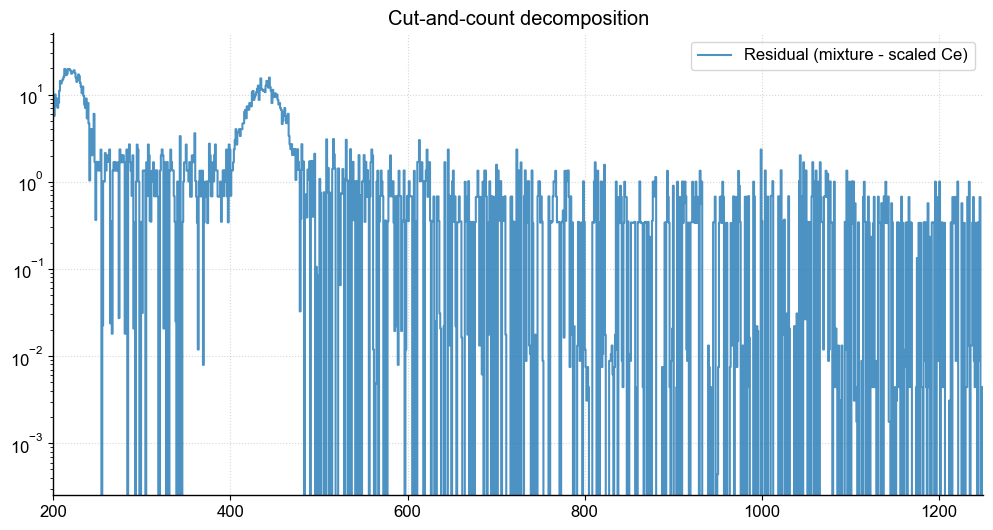

In [54]:
y_res = extra["y_residual"]
scale = extra["scale_ce"]

plt.figure()
# plt.step(x_keV, y_mix, where="mid", label="Mixture", alpha=0.8)
# plt.step(x_keV, scale*y_ce_template, where="mid", label=f"Scaled Ce template (x{scale:.3g})", alpha=0.8)
plt.step(x_keV, y_res, where="mid", label="Residual (mixture - scaled Ce)", alpha=0.8)
plt.yscale("log")
# plt.step(x_keV, y_ac_template, where="mid", label="Residual (mixture - scaled Ce)", alpha=0.8)
plt.xlim(200, 1250)

plt.legend()
plt.title("Cut-and-count decomposition")
plt.show()

In [55]:
# save
run_config = {
    "method": cfg.method_tag,
    "resolution_pct_fwhm": cfg.resolution_pct_fwhm,
    "nsigma": cfg.nsigma,
    "ce_peak_keV": cfg.ce_peak_keV,
    "ac_peak_keV": cfg.ac_peak_keV,
    "templates": {"ce134": {"experiment_id": exp_ce, "cal_tag": cal_tag, "label": ce_template_label}},
    "calibrations": {"ce": {"slope": slope_ce, "intercept": b_ce}, "ac": {"slope": slope_ac, "intercept": b_ac}},
}
run_id = ArtifactStore.make_run_id(run_config, prefix=cfg.method_tag)

store.save_cutcount_estimate(est, run_id=run_id)

NameError: name 'slope_ce' is not defined

In [56]:
est

CutCountEstimate(experiment_id='ANIL_MIX_SD__agg__bkgsub', label='1.953:3.906', activities_bq={'ce134': -219.49786161544822, 'ac225': 33.30124394831546}, uncertainties_bq={'ce134': 6.975121190094227, 'ac225': 6.792547917281435}, diagnostics={'method_tag': 'cutcount_ceac_v1', 'roi_keV': [200.0, 1250.0], 'resolution_pct_fwhm': 8.0, 'nsigma': 2.0, 'windows': {'ce134': {'center_keV': 1022.0, 'half_width_keV': 69.43524416135881}, 'ac225': {'center_keV': 218.0, 'half_width_keV': 14.811040339702762}}, 'counts': {'ce134_1022': 181.90000000000003, 'ce134_1022_sigma': 13.48703080740902, 'ce_template_1022': 184.33333333333331, 'ce_scale': 0.9867992766726946, 'ac225_residual': 463.5849969861361, 'ac225_residual_sigma': 21.5310240579991}, 'calibrations': {'ce134': {'slope_counts_per_bq': 1.933590892522804, 'intercept_counts': 606.3190661478615}, 'ac225': {'slope_counts_per_bq': 3.169800834708931, 'intercept_counts': 358.02668612192}}})

In [ ]:
end

# Loop

In [38]:
ce_labels  = list(anil_ce_cal.labels)
mix_labels = list(anil_mix_cal.labels)

cfg = CeAcCutCountConfig(
    resolution_pct_fwhm=8.0,
    nsigma=2.0,
    ce_peak_keV=1022.0,
    ac_peak_keV=218.0,
)

# Fit window calibrations ONCE from pure standards (outside sweep)
ce_window_cal, ce_eff_model = fit_window_cal_via_efficiency(
    cal=ce_cal_result,
    label_to_activity_bq=ce_truth_bq,
    iso="ce134",
    peak_keV=cfg.ce_peak_keV,
    resolution_pct_fwhm=cfg.resolution_pct_fwhm,
    nsigma=cfg.nsigma,
    model_name="ce134_win1022_counts_vs_bq_linear_v1",
)

ac_window_cal, ac_eff_model = fit_window_cal_via_efficiency(
    cal=ac_cal_result,
    label_to_activity_bq=ac_truth_bq,
    iso="ac225",
    peak_keV=cfg.ac_peak_keV,
    resolution_pct_fwhm=cfg.resolution_pct_fwhm,
    nsigma=cfg.nsigma,
    model_name="ac225_win218_counts_vs_bq_linear_v1",
)

# ---- Sweep ----
for mix_label in mix_labels:
    mix_spec = anil_mix_cal.calibrated[mix_label]

    x_keV = np.asarray(mix_spec["bin_centers_kev"], dtype=float)
    y_mix = np.asarray(mix_spec["counts_vals"], dtype=float)

    for ce_template_label in ce_labels:
        ce_tpl = anil_ce_cal.calibrated[ce_template_label]
        y_ce_template = np.asarray(ce_tpl["counts_vals"], dtype=float)

        cc_config = {
            "method": cfg.method_tag,
            "roi_keV": list(cfg.roi_keV),
            "resolution_pct_fwhm": cfg.resolution_pct_fwhm,
            "nsigma": cfg.nsigma,
            "ce_peak_keV": cfg.ce_peak_keV,
            "ac_peak_keV": cfg.ac_peak_keV,
            "templates": {
                "ce134": {"experiment_id": anil_ce_exp_id, "cal_tag": cal_tag, "label": ce_template_label},
            },
            "window_cals": {
                "ce134_1022": {
                    "slope_counts_per_bq": float(ce_window_cal.slope_counts_per_bq),
                    "intercept_counts": float(ce_window_cal.intercept_counts),
                },
                "ac225_peak": {
                    "slope_counts_per_bq": float(ac_window_cal.slope_counts_per_bq),
                    "intercept_counts": float(ac_window_cal.intercept_counts),
                },
            },
        }

        run_id = ArtifactStore.make_run_id(cc_config, prefix=cfg.method_tag)

        out_json = store._cutcount_sample_dir(anil_mix_exp_id, mix_label) / f"{run_id}.json"
        if out_json.exists():
            continue

        est, extra = estimate_ceac_mixture_cutcount(
            x_keV=x_keV,
            y_mix=y_mix,
            y_ce_template=y_ce_template,
            ce_cal=ce_window_cal,
            ac_cal=ac_window_cal,
            config=cfg,
        )

        est.experiment_id = anil_mix_exp_id
        est.label = mix_label
        est.diagnostics["run_config"] = cc_config

        store.save_cutcount_estimate(est, run_id=run_id)


NameError: name 'anil_ce_cal' is not defined